# SVAR — Blanchard-Quah Identification

## Methodological framework

We estimate a **trivariate SVAR** following Blanchard & Quah (1989) with:
- Brent crude oil price (external supply shock proxy)
- Industrial production growth (output)
- CPI inflation

**Identification restriction (Blanchard-Quah):** demand shocks have no long-run effect on output. This decomposes inflation into:
- **Oil shocks** → external, remain under EA membership
- **Supply shocks** → idiosyncratic to Ukraine (geopolitics, energy, agriculture), remain under EA membership
- **Demand shocks** → replaced by EA demand shocks under EA membership (ECB monetary policy)

**Counterfactual:** resimulate Ukraine's VAR replacing demand residuals with EA demand residuals, weighted by treatment intensity from Part A.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import linalg
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

cwd       = Path.cwd()
DATA_PROC = cwd.parent / "data" / "data_processed"
DATA_EXT  = cwd.parent / "data" / "data_external"
OUTPUTS   = cwd.parent.parent / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Paths OK")

Paths OK


## 1. Data loading

In [2]:
# Inflation panel
infl = pd.read_csv(DATA_PROC / "inflation_panel.csv",
                   parse_dates=["date"], index_col="date")
EA_COUNTRIES = [c for c in infl.columns if c != "UKR"]
ea_infl  = infl[EA_COUNTRIES].mean(axis=1).rename("ea_infl")
ukr_infl = infl["UKR"].rename("ukr_infl")

# External data
ext     = pd.read_csv(DATA_EXT / "external_data.csv",
                      parse_dates=["date"], index_col="date")
ukr_ip  = ext["ukr_ip"].rename("ukr_ip")
ea_ip   = ext["ea_ip"].rename("ea_ip")
brent   = ext["brent"].rename("brent")

# Build trivariate VAR datasets
ukr_var_data = pd.DataFrame({
    "brent":    brent,
    "ukr_ip":   ukr_ip,
    "ukr_infl": ukr_infl,
}).dropna()

ea_var_data = pd.DataFrame({
    "brent":   brent,
    "ea_ip":   ea_ip,
    "ea_infl": ea_infl,
}).dropna()

print(f"Ukraine VAR sample: {len(ukr_var_data)} obs | {ukr_var_data.index.min().date()} → {ukr_var_data.index.max().date()}")
print(f"EA VAR sample:      {len(ea_var_data)} obs | {ea_var_data.index.min().date()} → {ea_var_data.index.max().date()}")
print()
print(ukr_var_data.describe().round(2))

Ukraine VAR sample: 240 obs | 2006-01-01 → 2025-12-01
EA VAR sample:      214 obs | 2006-01-01 → 2023-10-01

        brent  ukr_ip  ukr_infl
count  240.00  240.00    240.00
mean    76.84   -2.97     11.75
std     23.63    9.43     11.19
min     18.38  -41.00     -1.20
25%     61.16   -8.40      5.76
50%     74.09    0.77      9.73
75%     94.04    4.13     14.47
max    132.72    8.41     60.91


## 2. Lag selection

In [3]:
p_ukr = VAR(ukr_var_data).select_order(maxlags=12).aic
p_ea  = VAR(ea_var_data).select_order(maxlags=12).aic

# Cap at 6 to preserve degrees of freedom
p_ukr = min(max(p_ukr, 1), 6)
p_ea  = min(max(p_ea,  1), 6)

print(f"Ukraine — selected lag (AIC, capped at 6): {p_ukr}")
print(f"EA      — selected lag (AIC, capped at 6): {p_ea}")

Ukraine — selected lag (AIC, capped at 6): 6
EA      — selected lag (AIC, capped at 6): 6


## 3. VAR estimation

In [4]:
res_ukr = VAR(ukr_var_data).fit(p_ukr)
res_ea  = VAR(ea_var_data).fit(p_ea)

print(f"Ukraine VAR({p_ukr}) — AIC: {res_ukr.aic:.3f}")
print(f"Ukraine sigma_u diag: {np.diag(res_ukr.sigma_u).round(3)}")
print()
print(f"EA VAR({p_ea}) — AIC: {res_ea.aic:.3f}")
print(f"EA sigma_u diag: {np.diag(res_ea.sigma_u).round(3)}")

Ukraine VAR(6) — AIC: 3.992
Ukraine sigma_u diag: [36.659  0.409  2.893]

EA VAR(6) — AIC: 3.774
EA sigma_u diag: [43.199 10.836  0.094]


## 4. Blanchard-Quah structural identification

Restriction: demand shocks have zero long-run effect on output.

Long-run multiplier: $C(1) = (I - A_1 - ... - A_p)^{-1}$

Cholesky of $C(1)\Sigma C(1)'$ gives the structural impact matrix $B_0$.

Variable ordering: **[Brent, IP, Inflation]**
→ 3 structural shocks: oil shock, supply shock, demand shock

In [5]:
def blanchard_quah(var_result, var_data, p):
    k = var_result.neqs
    A = np.zeros((k, k))
    for i in range(p):
        A += var_result.coefs[i]

    C1    = np.linalg.inv(np.eye(k) - A)
    Sigma = var_result.sigma_u
    M     = C1 @ Sigma @ C1.T
    P     = np.linalg.cholesky(M)
    B0    = np.linalg.inv(C1) @ P

    resid         = np.array(var_result.resid)
    struct_shocks = resid @ np.linalg.inv(B0).T
    idx           = var_data.index[p:]

    return pd.DataFrame(
        struct_shocks, index=idx,
        columns=["oil_shock", "supply_shock", "demand_shock"]
    ), B0, C1


shocks_ukr, B0_ukr, C1_ukr = blanchard_quah(res_ukr, ukr_var_data, p_ukr)
shocks_ea,  B0_ea,  C1_ea  = blanchard_quah(res_ea,  ea_var_data,  p_ea)

print("Ukraine structural shocks:")
print(shocks_ukr.describe().round(3))
print()
print("Shock correlations (should be ~0):")
print(shocks_ukr.corr().round(3))

Ukraine structural shocks:
       oil_shock  supply_shock  demand_shock
count    234.000       234.000       234.000
mean       0.000        -0.000         0.000
std        0.961         0.961         0.961
min       -3.478        -3.986        -4.331
25%       -0.650        -0.431        -0.387
50%        0.035         0.110        -0.001
75%        0.636         0.421         0.442
max        2.676         5.948         5.427

Shock correlations (should be ~0):
              oil_shock  supply_shock  demand_shock
oil_shock           1.0          -0.0           0.0
supply_shock       -0.0           1.0          -0.0
demand_shock        0.0          -0.0           1.0


## 5. Impulse Response Functions

Validation: demand shock must have zero cumulative effect on output at long horizon.

Long-run effect of demand shock on UA output: -3.8226 (target: ~0)
Long-run effect of demand shock on EA output: -0.2385 (target: ~0)


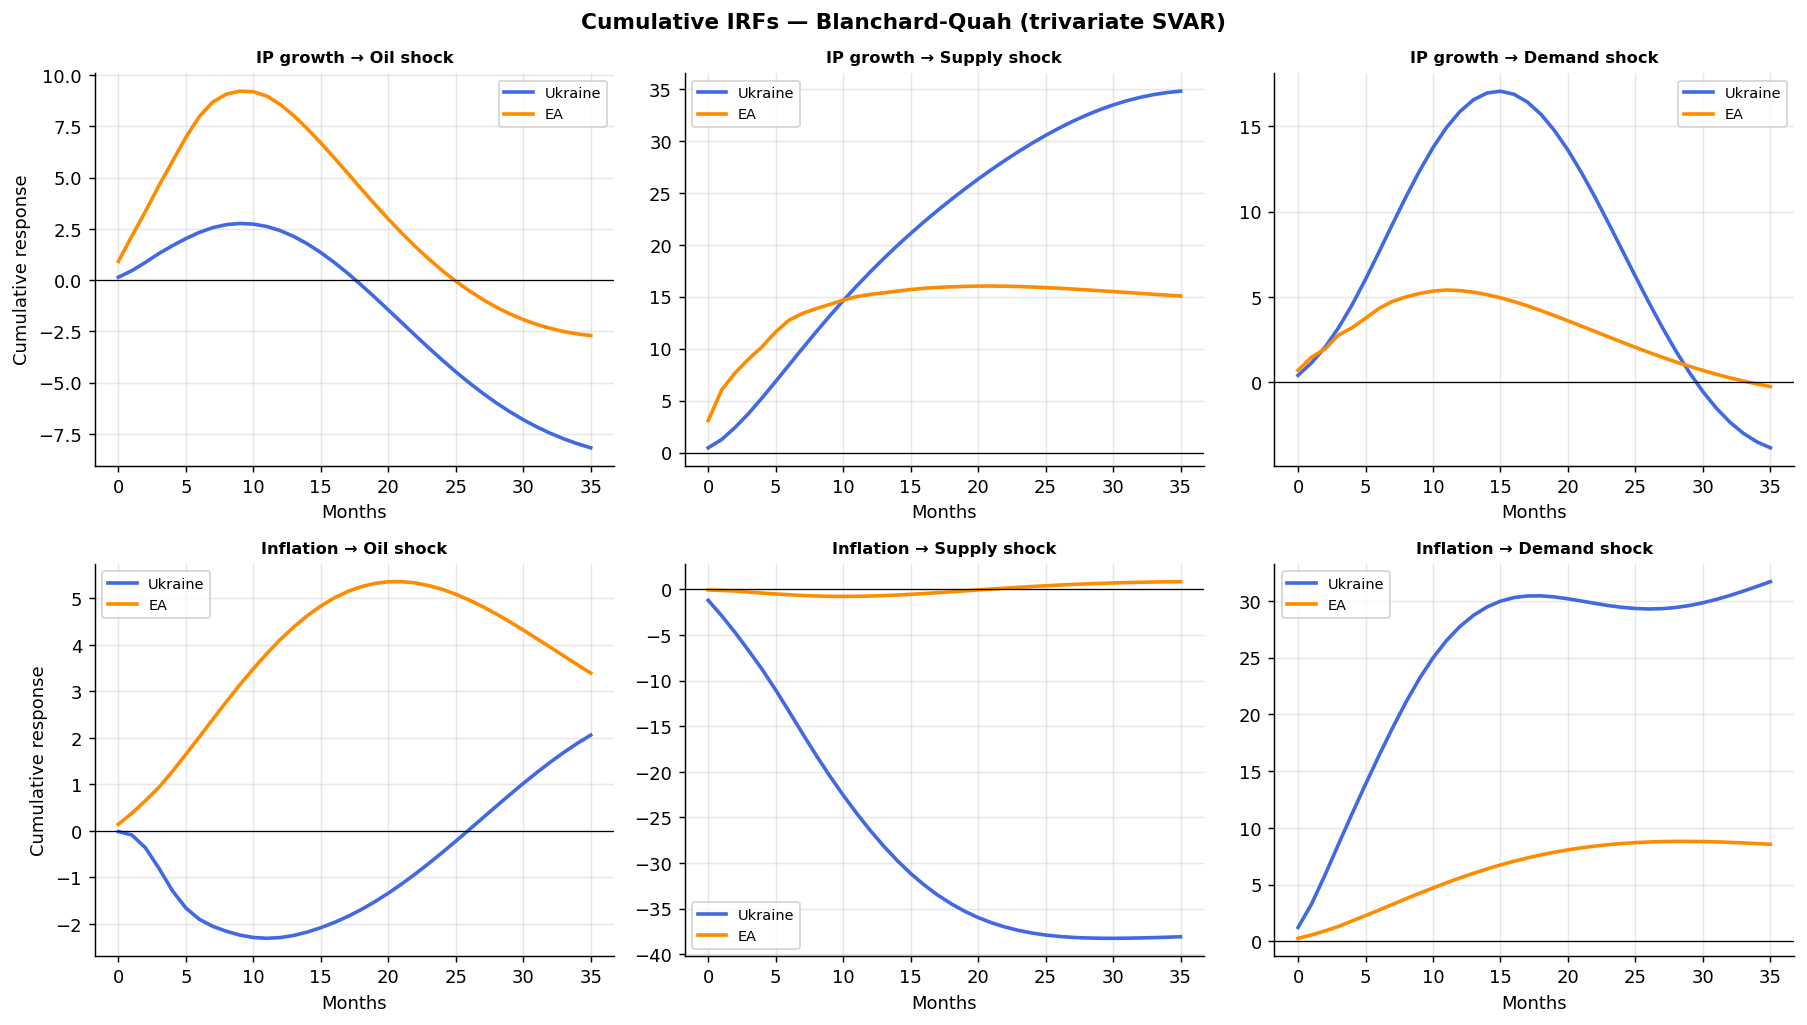

In [6]:
def compute_irf(B0, var_result, horizon=36):
    k = var_result.neqs
    p = var_result.k_ar
    phi = np.zeros((horizon, k, k))
    phi[0] = np.eye(k)
    for h in range(1, horizon):
        for j in range(min(h, p)):
            phi[h] += phi[h-1-j] @ var_result.coefs[j]
    irf = np.zeros((horizon, k, k))
    for h in range(horizon):
        irf[h] = phi[h] @ B0
    return irf


irf_ukr = compute_irf(B0_ukr, res_ukr, horizon=36)
irf_ea  = compute_irf(B0_ea,  res_ea,  horizon=36)

# Validation
print(f"Long-run effect of demand shock on UA output: {np.cumsum(irf_ukr[:, 1, 2])[-1]:.4f} (target: ~0)")
print(f"Long-run effect of demand shock on EA output: {np.cumsum(irf_ea[:,  1, 2])[-1]:.4f} (target: ~0)")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
resp_labels  = ["Brent", "IP growth", "Inflation"]
shock_labels = ["Oil shock", "Supply shock", "Demand shock"]

for j, resp in enumerate(resp_labels):
    for i, shock in enumerate(shock_labels):
        ax = axes[j//2 if j < 2 else 1, i] if j < 2 else axes[1, i]
        break

for i, shock in enumerate(shock_labels):
    for j, resp in enumerate(["IP growth", "Inflation"]):
        ax = axes[j, i]
        ax.plot(np.cumsum(irf_ukr[:, j+1, i]), color="royalblue", lw=2, label="Ukraine")
        ax.plot(np.cumsum(irf_ea[:,  j+1, i]), color="darkorange", lw=2, label="EA")
        ax.axhline(0, color="black", lw=0.7)
        ax.set_title(f"{resp} → {shock}", fontsize=9, fontweight="bold")
        ax.set_xlabel("Months")
        if i == 0: ax.set_ylabel("Cumulative response")
        ax.legend(fontsize=8)

plt.suptitle("Cumulative IRFs — Blanchard-Quah (trivariate SVAR)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "fig5_irf_blanchard_quah.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Structural counterfactual

Under EA membership:
- **Oil shocks** → unchanged (external, common to all)
- **Supply shocks** → unchanged (Ukraine's idiosyncratic real shocks)
- **Demand shocks** → replaced by EA demand residuals (ECB policy replaces NBU policy)

Treatment intensity weights from Part A:
- Peg periods (2006-08, 2010-14): weight = 0.3 → Ukraine already had limited monetary sovereignty
- Crisis episodes (2008-09, 2014-15, 2022): weight = 1.0 → full monetary sovereignty exercised
- IT period (2016-2022): weight = 0.6 → partial sovereignty

We resimulate Ukraine's VAR with the counterfactual demand residuals.

In [7]:
common_idx = shocks_ukr.index.intersection(shocks_ea.index)
print(f"Common index: {len(common_idx)} obs | {common_idx.min().date()} → {common_idx.max().date()}")

# Treatment intensity weights
weights = pd.Series(0.6, index=common_idx)
weights.loc["2006-01":"2008-03"] = 0.3
weights.loc["2010-01":"2014-01"] = 0.3
weights.loc["2008-04":"2009-12"] = 1.0
weights.loc["2014-02":"2015-12"] = 1.0
weights.loc["2022-02":"2023-09"] = 1.0

# Rescale EA demand residuals to Ukraine's demand residual variance
resid_ukr = np.array(res_ukr.resid)
resid_ea  = np.array(res_ea.resid)
n = min(len(resid_ukr), len(resid_ea), len(common_idx))

scale = resid_ukr[:n, 2].std() / (resid_ea[:n, 2].std() + 1e-8)
print(f"Rescaling factor (UA/EA demand residual std): {scale:.3f}")

# Build counterfactual residuals
resid_cf = resid_ukr.copy()
w_arr    = weights.values[:n]
resid_cf[:n, 2] = (w_arr * resid_ea[:n, 2] * scale +
                   (1 - w_arr) * resid_ukr[:n, 2])

# Resimulate VAR with counterfactual residuals
ukr_arr   = np.array(ukr_var_data.loc[common_idx[0]:])
coefs     = res_ukr.coefs
intercept = res_ukr.intercept
T         = len(common_idx)

y_cf      = np.zeros((T, 3))
y_cf[:p_ukr] = ukr_arr[:p_ukr]

for t in range(p_ukr, T):
    y_cf[t] = intercept.copy()
    for j in range(p_ukr):
        y_cf[t] += coefs[j] @ y_cf[t - 1 - j]
    y_cf[t] += resid_cf[t - p_ukr]

cf_scaled       = pd.Series(y_cf[:, 2], index=common_idx, name="counterfactual_svar")
ukr_infl_common = ukr_infl.reindex(common_idx)
ea_infl_common  = ea_infl.reindex(common_idx)
gap             = ukr_infl_common - cf_scaled

print("\nCounterfactual:")
print(cf_scaled.describe().round(2))
print(f"\nGap: {gap.min():.1f}pp to {gap.max():.1f}pp")

Common index: 208 obs | 2006-07-01 → 2023-10-01
Rescaling factor (UA/EA demand residual std): 5.863

Counterfactual:
count    208.00
mean      13.07
std       11.26
min       -0.83
25%        4.09
50%       10.57
75%       18.40
max       58.64
Name: counterfactual_svar, dtype: float64

Gap: -45.4pp to 49.6pp


## 7. Final figure

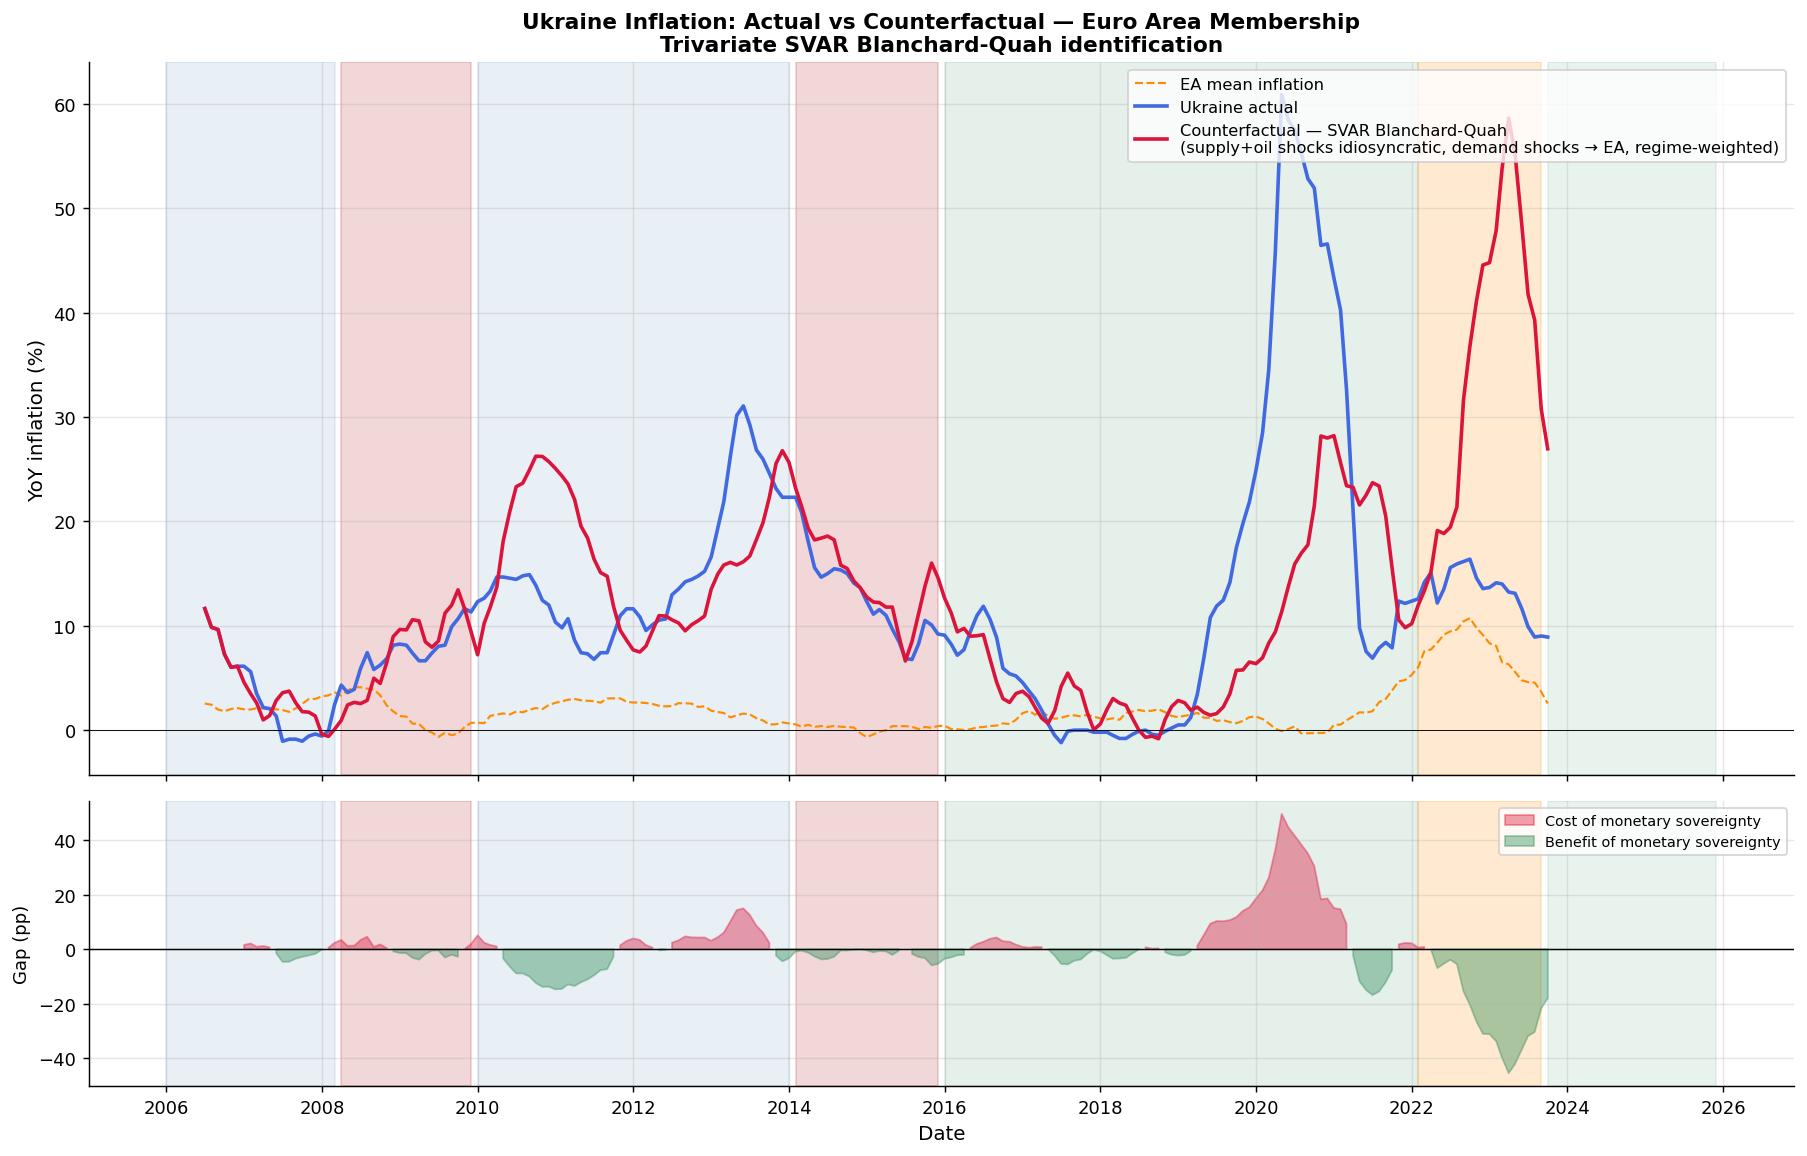

Figure saved.


In [8]:
REGIMES = [
    ("2006-01", "2008-03", "USD peg I",          "steelblue",  0.12),
    ("2008-04", "2009-12", "GFC devaluation",     "firebrick",  0.18),
    ("2010-01", "2014-01", "USD peg II",          "steelblue",  0.12),
    ("2014-02", "2015-12", "Crimea/Donbas",       "firebrick",  0.18),
    ("2016-01", "2022-02", "Inflation targeting", "seagreen",   0.12),
    ("2022-02", "2023-09", "Wartime peg",         "darkorange", 0.18),
    ("2023-10", "2025-12", "Managed float",       "seagreen",   0.10),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={"height_ratios": [2.5, 1]})
ax, ax2 = axes

for start, end, _, color, alpha in REGIMES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)

ax.plot(ea_infl_common.index, ea_infl_common, color="darkorange",
        lw=1.2, ls="--", label="EA mean inflation")
ax.plot(ukr_infl_common.index, ukr_infl_common, color="royalblue",
        lw=2, label="Ukraine actual")
ax.plot(cf_scaled.index, cf_scaled, color="crimson", lw=2,
        label="Counterfactual — SVAR Blanchard-Quah\n(supply+oil shocks idiosyncratic, demand shocks → EA, regime-weighted)")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("YoY inflation (%)", fontsize=11)
ax.set_title(
    "Ukraine Inflation: Actual vs Counterfactual — Euro Area Membership\n"
    "Trivariate SVAR Blanchard-Quah identification",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")

ax2.fill_between(gap.index, gap, 0, where=gap > 0,
                 color="crimson", alpha=0.4, label="Cost of monetary sovereignty")
ax2.fill_between(gap.index, gap, 0, where=gap < 0,
                 color="seagreen", alpha=0.4, label="Benefit of monetary sovereignty")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Gap (pp)", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=8, loc="upper right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(OUTPUTS / "fig6_counterfactual_svar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 8. Period-by-period summary

In [9]:
episodes = [
    ("2006-01", "2008-03", "USD peg I"),
    ("2008-04", "2009-12", "GFC 2008-09"),
    ("2010-01", "2014-01", "USD peg II"),
    ("2014-02", "2015-12", "Crimea/Donbas"),
    ("2016-01", "2022-02", "Inflation targeting"),
    ("2022-02", "2023-09", "Wartime"),
]

print(f"{'Period':<25} {'Actual':>8} {'CF':>8} {'Gap':>8} {'Weight':>8}")
print("-" * 60)
for s, e, label in episodes:
    m = (gap.index >= s) & (gap.index <= e)
    if m.sum() > 0:
        a = ukr_infl_common[m].mean()
        c = cf_scaled[m].mean()
        g = gap[m].mean()
        w = weights.reindex(gap.index[m]).mean()
        print(f"{label:<25} {a:>7.1f}%  {c:>7.1f}%  {g:>+7.1f}pp  {w:>7.1f}")

Period                      Actual       CF      Gap   Weight
------------------------------------------------------------
USD peg I                     3.3%      3.8%     -0.6pp      0.3
GFC 2008-09                   7.4%      7.6%     -0.1pp      1.0
USD peg II                   15.1%     16.4%     -1.3pp      0.3
Crimea/Donbas                12.9%     14.7%     -1.8pp      1.0
Inflation targeting          13.9%      8.5%     +5.4pp      0.6
Wartime                      13.4%     34.7%    -21.3pp      1.0


In [10]:
results = pd.DataFrame({
    "ukr_actual":           ukr_infl_common,
    "ea_mean":              ea_infl_common,
    "counterfactual_svar":  cf_scaled,
    "gap_svar":             gap,
    "treatment_weight":     weights,
})
results.to_csv(DATA_PROC / "svar_counterfactual.csv")
print("Saved → data_processed/svar_counterfactual.csv")

Saved → data_processed/svar_counterfactual.csv
